# Download .tenv3 Files

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import wget

In [9]:
# Read NGL_Greece_Stations.csv
stations = pd.read_csv("NGL_Greece_Stations.csv")
sta_ids = stations['Station_ID'].tolist()
latitudes = stations['Latitude'].tolist()
longitude = stations['Longitude'].tolist()

# Download all files
for station in sta_ids:
        url = f"https://geodesy.unr.edu/gps_timeseries/IGS20/tenv3/EU/{station.upper()}.EU.tenv3"
        wget.download(url, out=f"GNSS_Bayesian/")

100% [............................................................................] 300696 / 300696

# Compute Distances

In [11]:
from obspy import read_events
from obspy import UTCDateTime
from obspy.geodetics import gps2dist_azimuth

In [16]:
# Save Station Data in Dataframe
df = pd.DataFrame({
    "Station_ID":sta_ids,
    "Latitude":latitudes,
    "Longitude":longitude
})
# Read earthquakes in Big10_Greece_Seismicity.xml
big10_catalog = read_events("Big10_Greece_Seismicity.xml")

# Distance from Epicenter per Earthquake lists

j=0
for j, event in enumerate(big10_catalog, start=1):
    # For each earthquake, compute distance
    origin = event.preferred_origin() or event.origins[0]
    evlat = origin.latitude #degN
    evlon = origin.longitude #degE

    for i in range(len(sta_ids)):
        eq_distances = [
            gps2dist_azimuth(evlat, evlon, lat, lon)[0] 
            for lat, lon in zip(latitudes, longitude)
        ]
    
    df[f"EQ{j}"] = eq_distances

df.to_csv("GNSS_Bayesian/Distances.csv", index=False)

# Arange from least to most distance from epicenter

In [21]:
df = pd.read_csv("GNSS_Bayesian/Distances.csv")

for i in range(1,11):
    eq_name = f"EQ{i}"
    df_sorted = df[["Station_ID", eq_name]].sort_values(by=eq_name)
    df_sorted.to_csv(f"GNSS_Bayesian/{eq_name}/{eq_name}.csv", index=False)

# Apply Bayesiano

In [1]:
%%bash

t1_list=( # A year before event
    None
    2005.0192 # 2006-01-08
    2007.1202 # 2008-02-14
    2007.1202 # 2008-02-14
    2012.7781 # 2013-10-12
    2013.3918 # 2014-05-24
    2014.8767 # 2015-11-17
    2016.5479 # 2017-07-20
    2017.8137 # 2018-10-25
    2019.3333 # 2020-05-02
    2019.8279 # 2020-10-30
)

t2_list=( # A year after event
    None
    2007.0192 # 2006-01-08
    2009.1202 # 2008-02-14
    2009.1202 # 2008-02-14
    2014.7781 # 2013-10-12
    2015.3918 # 2014-05-24
    2016.8767 # 2015-11-17
    2018.5479 # 2017-07-20
    2019.8137 # 2018-10-25
    2021.3333 # 2020-05-02
    2021.8279 # 2020-10-30
)

dirEXE=/mnt/c/Users/Bea/Downloads/Okada/Refining_Thesis/GNSS_Bayesian # Contains Executables
cd $dirEXE # Go to executables folder

for i in $(seq 1 10); do
    t1=${t1_list[$i]}
    t2=${t2_list[$i]}

    dirIN="${dirEXE}" # Input Folder
    dirOUT="${dirEXE}/EQ${i}" # Output Folder

    files=("$dirIN"/*.EU.tenv3)

    if [ ! -e "${files[0]}" ]; then
        continue
    fi

    # For every .tenv3 file in the folder
    for f in "${files[@]}"; do
        sta=$(basename "$f" .EU.tenv3) # Station Code/ Identifier
        rm -f serv.inp serv.p_tau serv.bayes # Delete residual files from prev run
    
        # Reads file "$f", filters in range [t1,t2], and extracts 3:Decimal Year and 9:East to serv.inp
        gawk -v tin="$t1" -v tout="$t2" -v c=9 'NR>1 && $3>=tin && $3<=tout {print $3, $c}' "$f" > serv.inp
        if [ -s serv.inp ]; then
            octave -q < input_cycleslip.m
            [ -f serv.bayes ] && cp serv.bayes "$dirOUT/$sta.E.bayes.out"
            [ -f serv.p_tau ] && cp serv.p_tau "$dirOUT/$sta.E.bayes.p_tau"
        else
            echo "Warning: No data for $sta in window $t1 - $t2"
        fi
        
        rm -f serv.inp serv.p_tau serv.bayes # Delete residual files from prev run
    
        # Reads file "$f", filters in range [t1,t2], and extracts 3:Decimal Year and 11:North to serv.inp
        gawk -v tin="$t1" -v tout="$t2" -v c=11 'NR>1 && $3>=tin && $3<=tout {print $3, $c}' "$f" > serv.inp
        if [ -s serv.inp ]; then
            octave -q < input_cycleslip.m
            [ -f serv.bayes ] && cp serv.bayes "$dirOUT/$sta.N.bayes.out"
            [ -f serv.p_tau ] && cp serv.p_tau "$dirOUT/$sta.N.bayes.p_tau"
        else
            echo "Warning: No data for $sta in window $t1 - $t2"
        fi
        
        rm -f serv.inp serv.p_tau serv.bayes # Delete residual files from prev run
    
        # Reads file "$f", filters in range [t1,t2], and extracts 3:Decimal Year and 13:Up to serv.inp
        gawk -v tin="$t1" -v tout="$t2" -v c=13 'NR>1 && $3>=tin && $3<=tout {print $3, $c}' "$f" > serv.inp
        if [ -s serv.inp ]; then
            octave -q < input_cycleslip.m
            [ -f serv.bayes ] && cp serv.bayes "$dirOUT/$sta.U.bayes.out"
            [ -f serv.p_tau ] && cp serv.p_tau "$dirOUT/$sta.U.bayes.p_tau"
        else
            echo "Warning: No data for $sta in window $t1 - $t2"
        fi

        rm -f serv.inp serv.p_tau serv.bayes
    done
done

tau0 = 2016.178000000000
tau0 = 2016.429800000000
tau0 = 2016.249100000000
tau0 = 2015.156700000000
tau0 = 2015.923300000000
tau0 = 2015.386700000000
tau0 = 2015.170400000000
tau0 = 2015.917900000000
tau0 = 2015.770000000000
tau0 = 2016.640700000000
tau0 = 2016.413400000000
tau0 = 2016.783000000000
tau0 = 2015.170400000000
tau0 = 2015.214200000000
tau0 = 2015.386700000000
tau0 = 2015.896000000000
tau0 = 2016.427100000000
tau0 = 2016.391500000000
tau0 = 2015.603000000000
tau0 = 2015.425100000000
tau0 = 2015.778200000000
tau0 = 2015.553700000000
tau0 = 2015.405900000000
tau0 = 2015.808400000000
tau0 = 2016.572200000000
tau0 = 2016.627000000000
tau0 = 2016.679000000000
tau0 = 2015.641300000000
tau0 = 2016.345000000000
tau0 = 2016.492800000000
tau0 = 2015.849400000000
tau0 = 2015.849400000000
tau0 = 2015.849400000000
tau0 = 2016.038300000000
tau0 = 2016.016400000000
tau0 = 2015.917900000000
tau0 = 2015.170400000000
tau0 = 2015.496200000000
tau0 = 2015.507200000000
tau0 = 2016.112300000000


    posterior_cont_gen at line 177 column 9

    posterior_cont_gen at line 183 column 15

error: 'muk' undefined near line 205, column 7
error: called from
    posterior_cont_gen at line 205 column 6


tau0 = 2016.339500000000


    posterior_cont_gen at line 177 column 9

    posterior_cont_gen at line 183 column 15

error: 'muk' undefined near line 205, column 7
error: called from
    posterior_cont_gen at line 205 column 6


tau0 = 2016.339500000000


...

tau0 = 2021.522200000000


    posterior_cont_gen at line 183 column 15

error: 'muk' undefined near line 205, column 7
error: called from
    posterior_cont_gen at line 205 column 6


tau0 = 2021.522200000000


    posterior_cont_gen at line 183 column 15

error: 'muk' undefined near line 205, column 7
error: called from
    posterior_cont_gen at line 205 column 6


tau0 = 2020.167000000000
tau0 = 2021.155400000000
tau0 = 2021.429200000000
tau0 = 2020.219000000000
tau0 = 2020.339500000000
tau0 = 2020.810400000000
tau0 = 2020.722800000000
tau0 = 2020.624200000000
tau0 = 2020.802200000000
tau0 = 2021.793300000000
tau0 = 2021.787800000000
tau0 = 2021.790600000000
tau0 = 2020.706400000000
tau0 = 2020.706400000000
tau0 = 2020.799500000000
tau0 = 2020.167000000000
tau0 = 2020.829600000000
tau0 = 2020.802200000000
tau0 = 2020.134200000000
tau0 = 2020.134200000000
tau0 = 2021.481200000000
tau0 = 2021.590700000000
tau0 = 2021.650900000000
tau0 = 2020.520200000000
tau0 = 2020.180700000000
tau0 = 2021.122500000000
tau0 = 2020.802200000000
tau0 = 2020.449000000000
tau0 = 2020.057500000000
tau0 = 2020.019200000000
tau0 = 2020.205300000000
tau0 = 2020.605100000000
tau0 = 2020.772100000000
tau0 = 2019.953500000000
tau0 = 2019.953500000000
tau0 = 2019.953500000000
tau0 = 2020.208100000000
tau0 = 2020.219000000000
tau0 = 2020.772100000000
tau0 = 2020.117700000000


## Read the displacement corresponding to each earthquake and write to file

In [2]:
%%bash

events=( # minus 0.0001 for all of them for 52 min consideration
    None
    2006.0191 # 2006-01-08 
    2008.1201 # 2008-02-14
    2008.1201 # 2008-02-14
    2013.7780 # 2013-10-12
    2014.3917 # 2014-05-24
    2015.8766 # 2015-11-17
    2017.5478 # 2017-07-20
    2018.8136 # 2018-10-25
    2020.3332 # 2020-05-02
    2020.8278 # 2020-10-30
)

dirEXE=/mnt/c/Users/Bea/Downloads/Okada/Refining_Thesis/GNSS_Bayesian # Contains Executables
disp=(
    "E"
    "N"
    "U"
)

cd ${dirEXE} || exit 1

for i in $(seq 1 10); do # For each quake
    event=${events[$i]}

    dirIN=${dirEXE}/EQ${i} # Input Folder

    for g in ${disp[@]}; do # For each component of displacement
        files=("$dirIN"/*."${g}".bayes.p_tau)

        if [ ! -e "${files[0]}" ]; then
            continue
        fi

        # For every .p_tau file
        for f in "${files[@]}"; do
            sta=$(basename "$f" ."${g}".bayes.p_tau) # Station Code/ Identifier
            gawk -v EQ="$i" -v comp="$g" -v sta="$sta" -v val="${event}" -v OFS="\t" '
                $1 >= val {
                    print EQ, comp, sta, $1, val, $2, $3
                    found = 1
                    exit
                }
            ' "$f" | tee -a GNSSTimeSeries.txt 
        done
    done
done

1	E	AKYR	2006.17110	2006.0191	0.00166	-0.00632
1	E	ANOP	2006.02050	2006.0191	0.00000	0.00252
1	E	ARKI	2006.14650	2006.0191	0.00000	0.00265
1	E	ATRS	2006.02050	2006.0191	0.00000	0.00854
1	E	AUT1	2006.02050	2006.0191	0.00000	0.00514
1	E	BER2	2006.02050	2006.0191	0.00000	0.00199
1	E	DION	2006.44760	2006.0191	0.01318	-0.01193
1	E	EYPA	2006.43120	2006.0191	0.00000	0.00151
1	E	GVDS	2006.48600	2006.0191	0.00000	0.00000
1	E	KATC	2006.02050	2006.0191	0.00000	0.00427
1	E	KERA	2006.34630	2006.0191	0.00000	0.00000
1	E	KERY	2006.02050	2006.0191	0.00001	0.00604
1	E	KITH	2006.02050	2006.0191	0.00000	0.00229
1	E	KOUN	2006.45860	2006.0191	0.84926	-0.01597
1	E	KRYO	2006.02050	2006.0191	0.00000	0.00604
1	E	LFKD	2006.02050	2006.0191	0.00000	0.00177
1	E	LIDO	2006.46130	2006.0191	0.00000	-0.01002
1	E	MEN1	2006.02050	2006.0191	0.00000	0.00357
1	E	MET0	2006.82000	2006.0191	0.00000	0.00000
1	E	MET4	2006.02050	2006.0191	0.00000	0.00492
1	E	MLOS	2006.02050	2006.0191	0.00000	0.00450
1	E	NEA1	2006.02050	2006.0191	

Filter GNSSTimeSeries.text by hand like so:
1. Only probabilities greater than 0.
2. Only difference in epoch less than 0.01 decimal year.
3. Only displacements more than 1 mm.

Then per earthquake, arrange stations by increasing distance from epicenter.

After doing all this, your stations must be easier to plot as a time series and map geographically. I hope.

# Plot Time Series for all stations with nonzero posterior probability within 0.01 decimal year of the event.  (.out files)

Some lines are only for the filtered data with probability>0.1. The alternative is just nonzero probability, which can be as low as 0.00001.

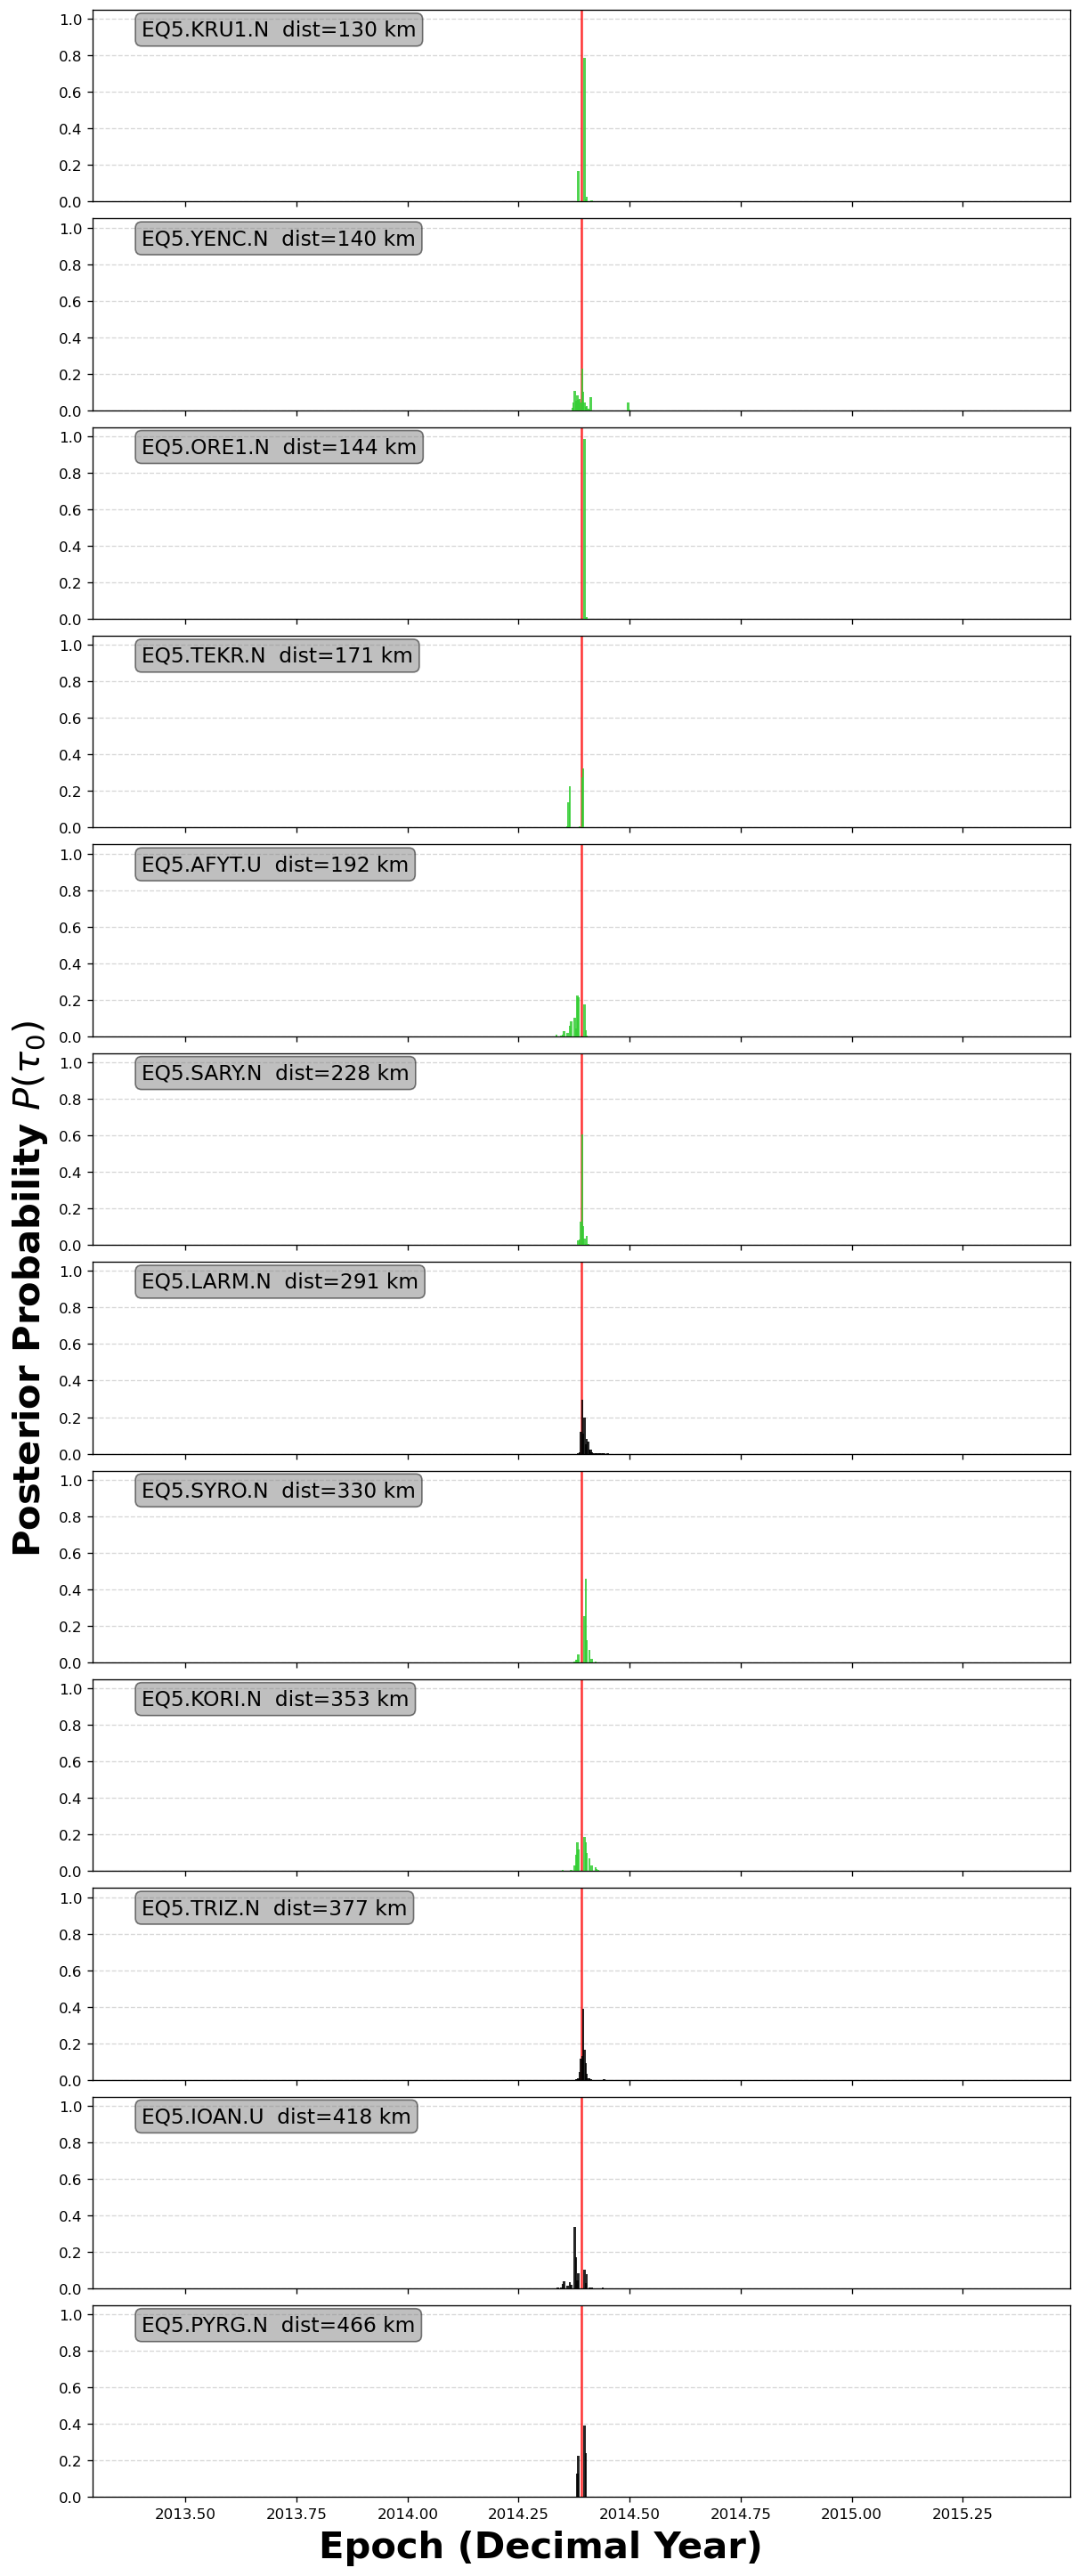

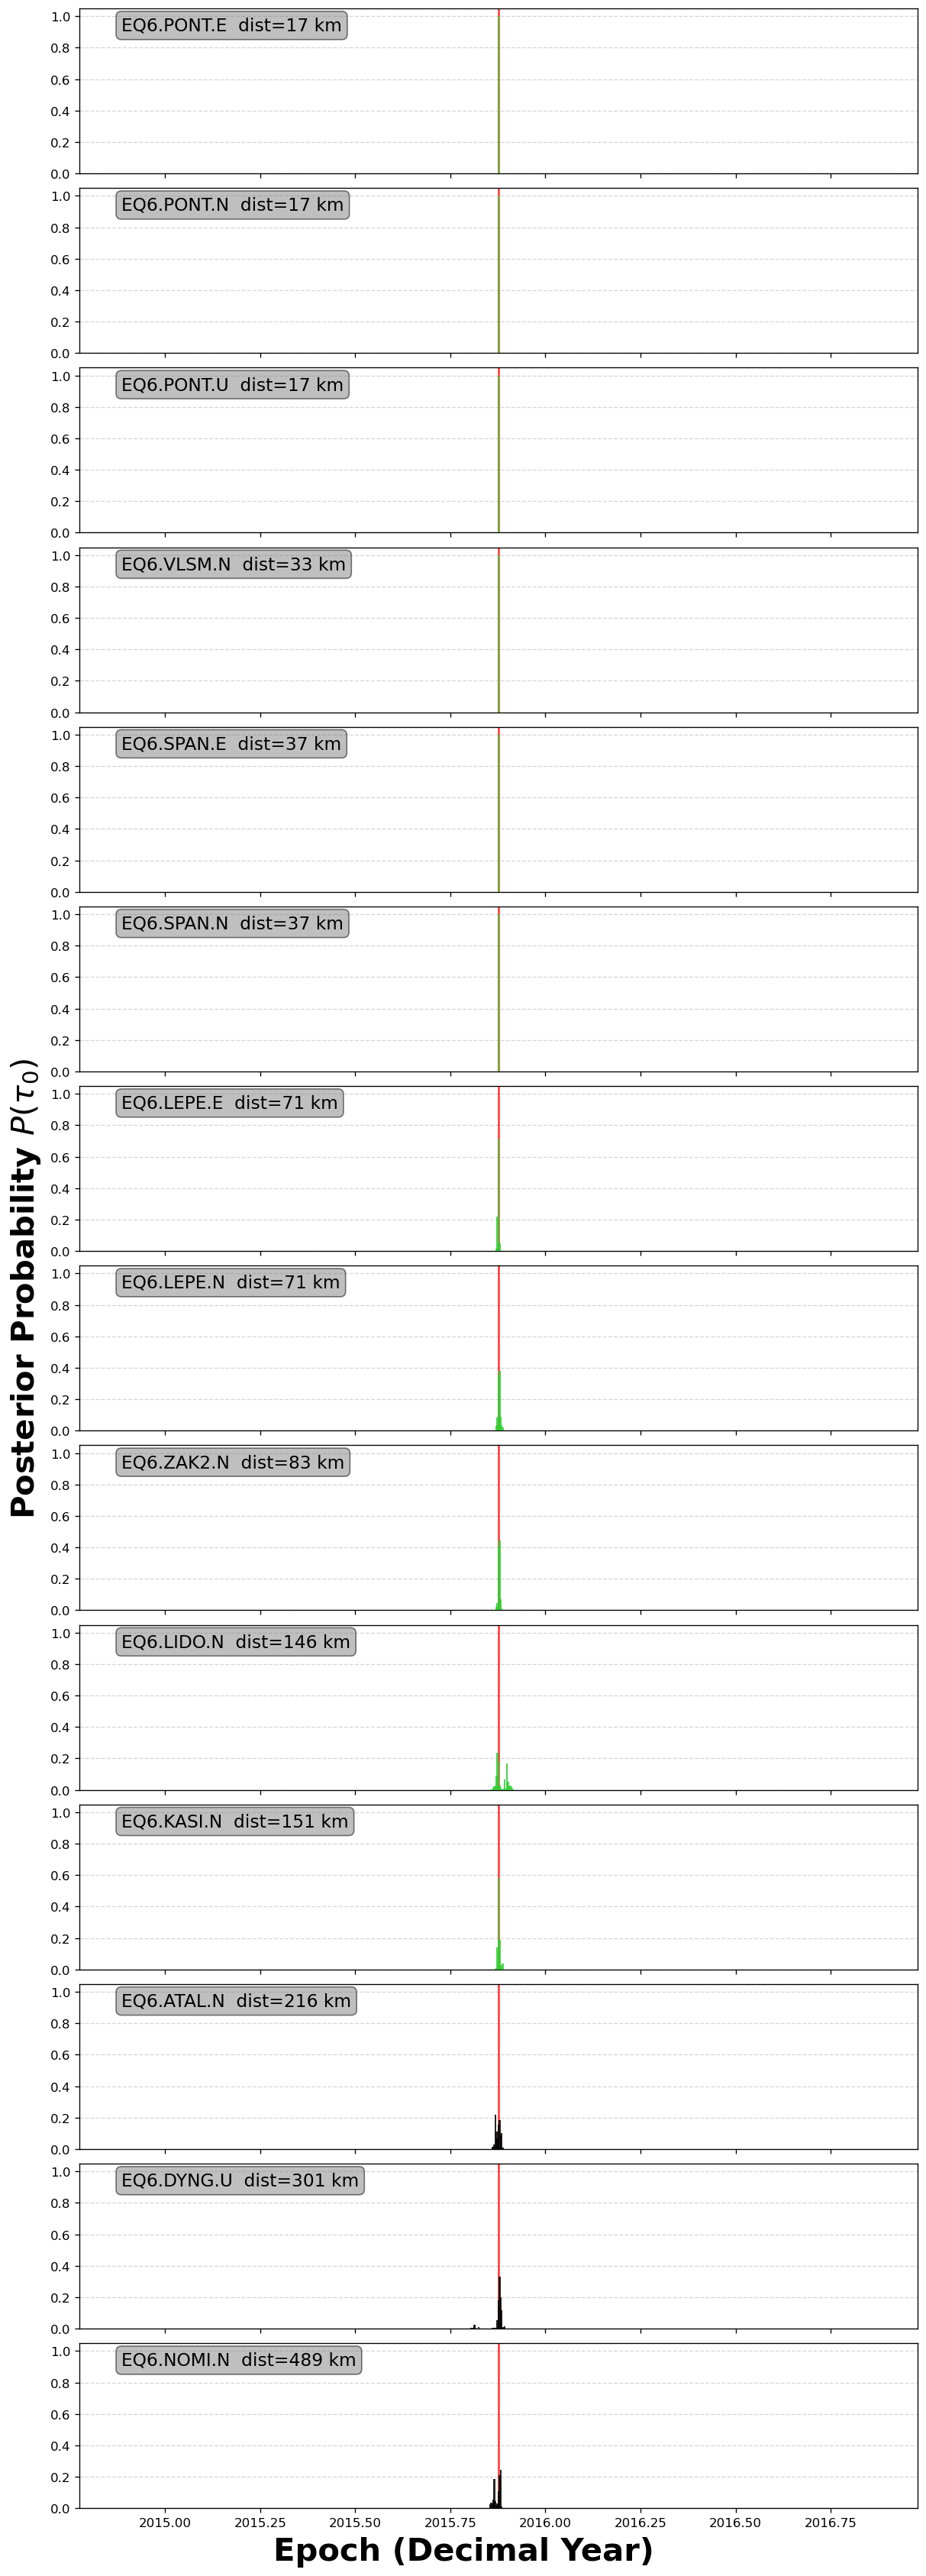

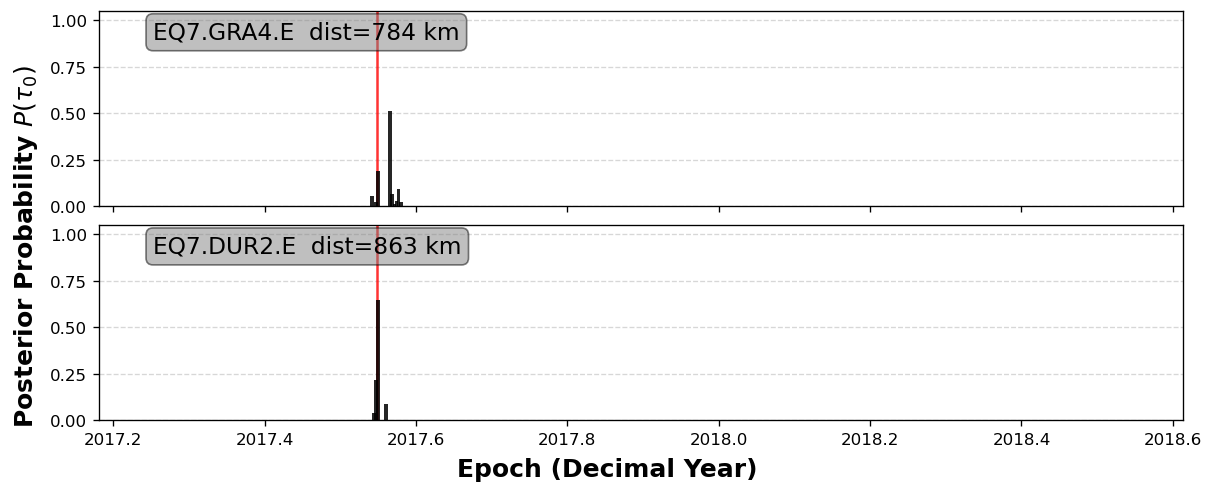

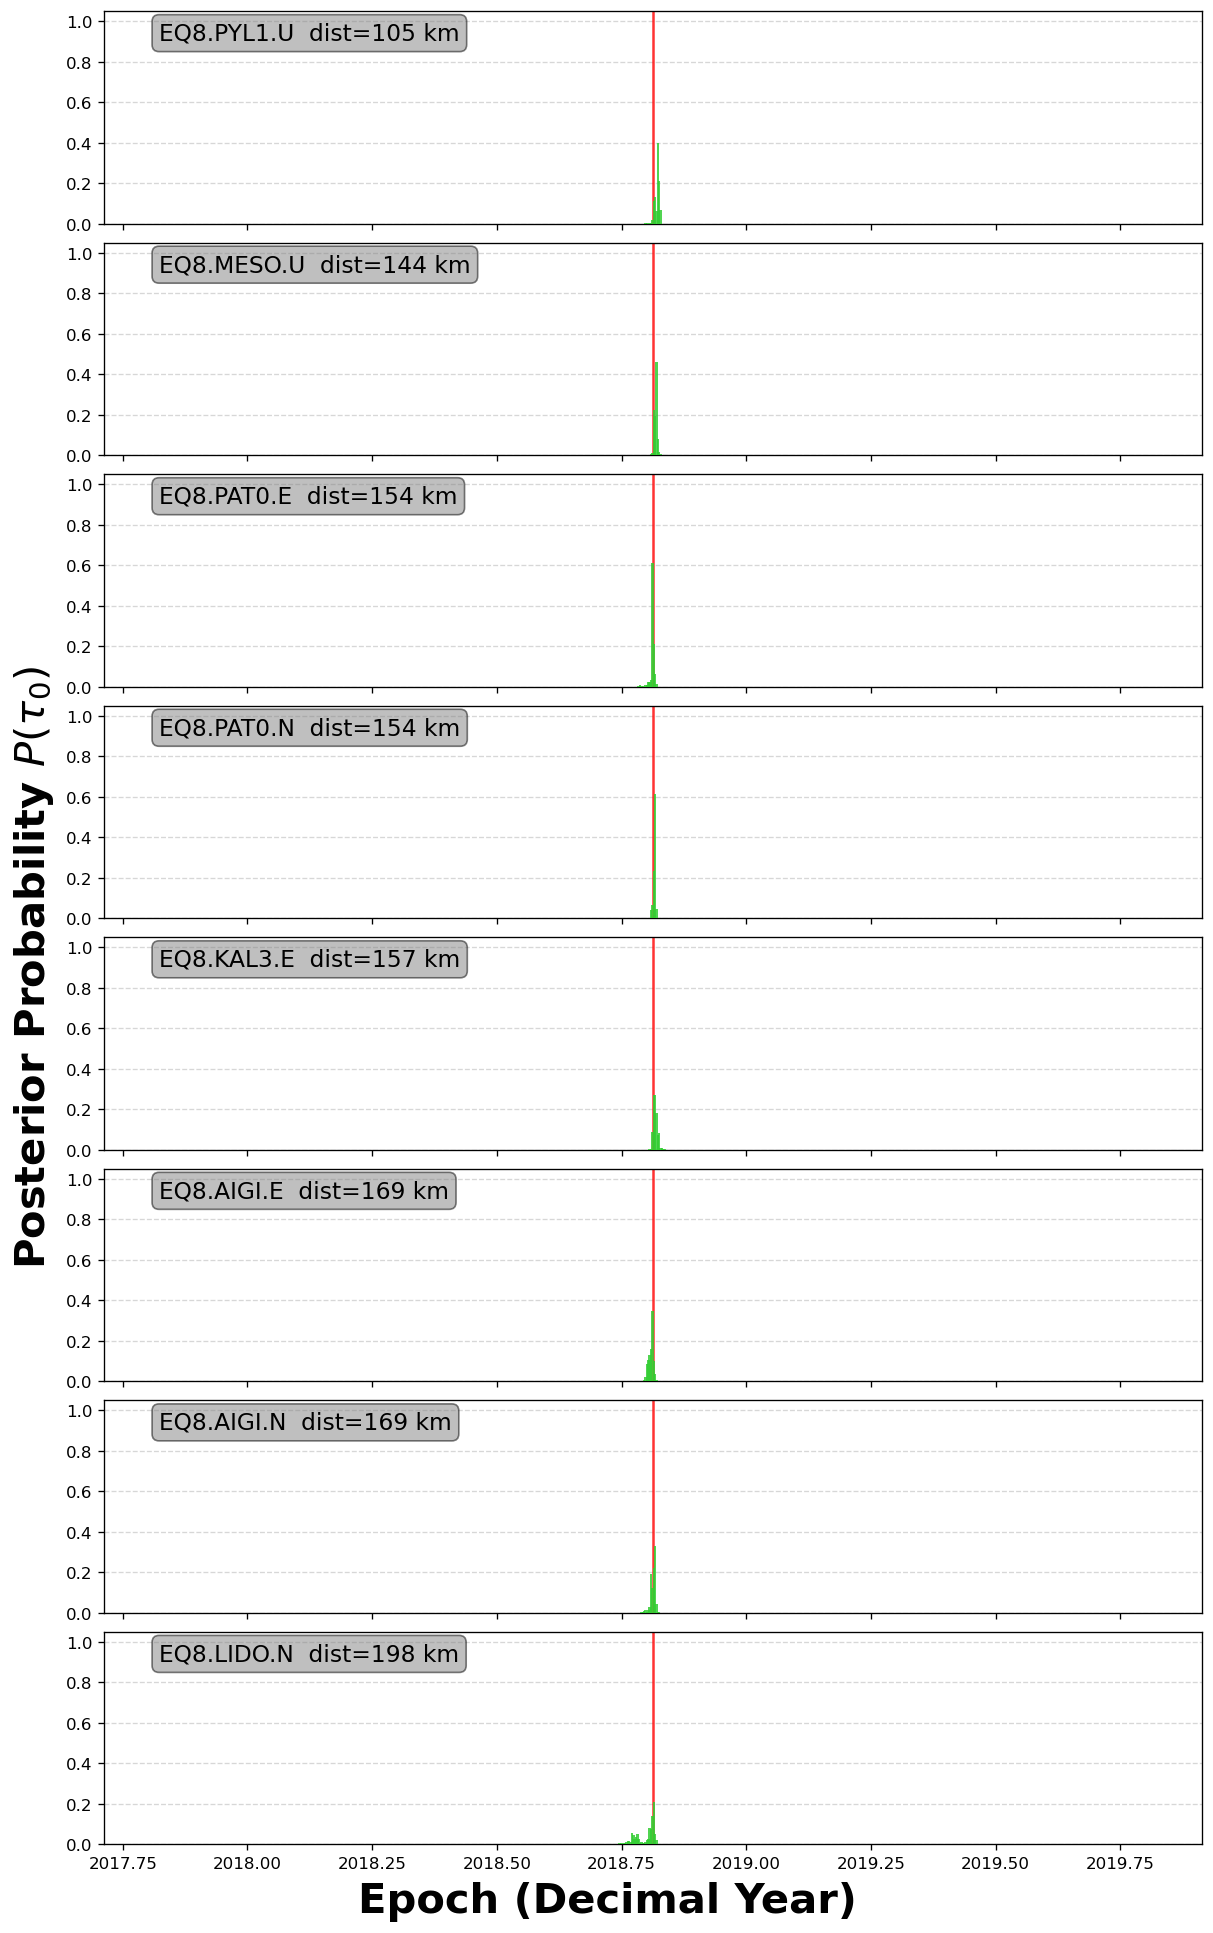

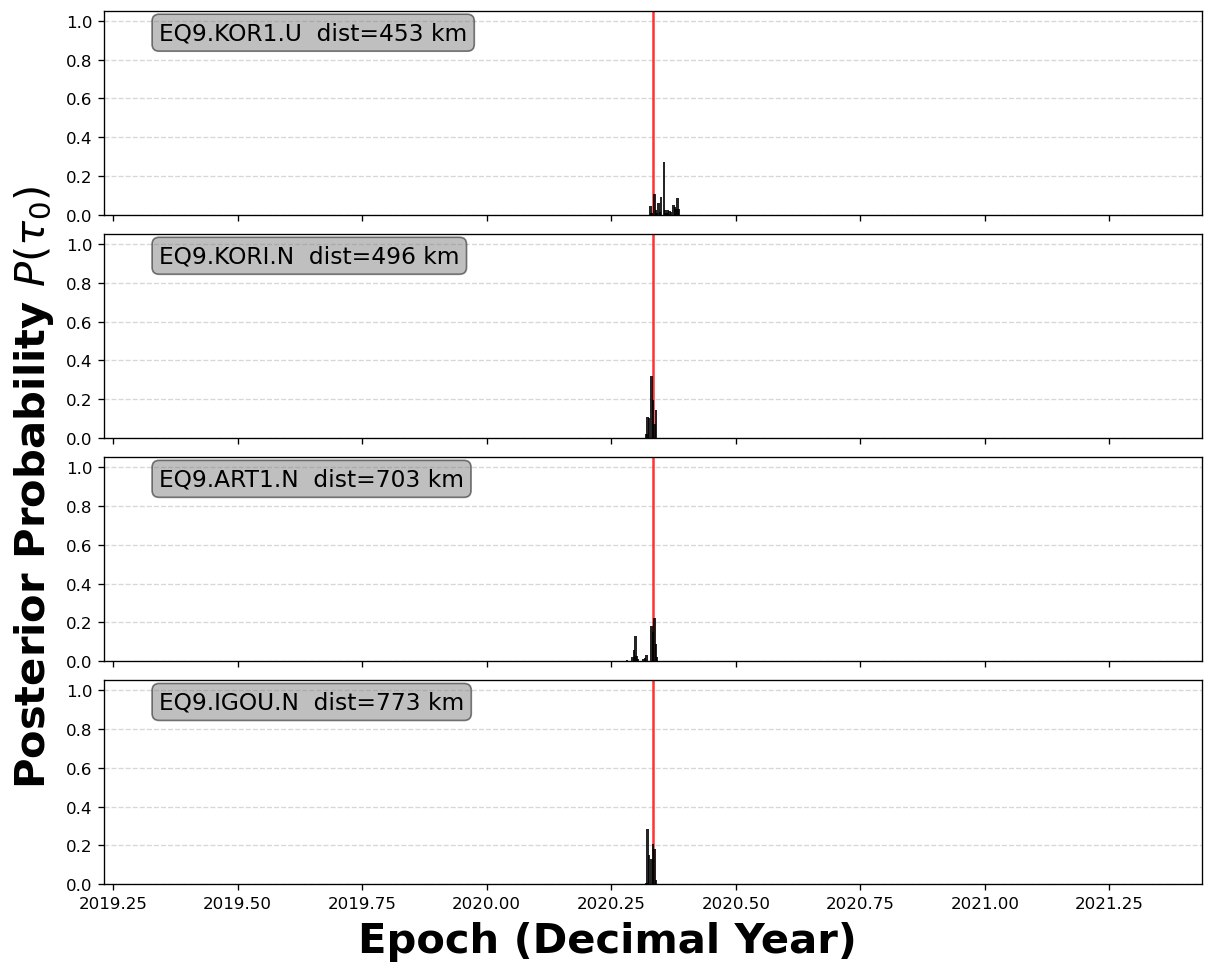

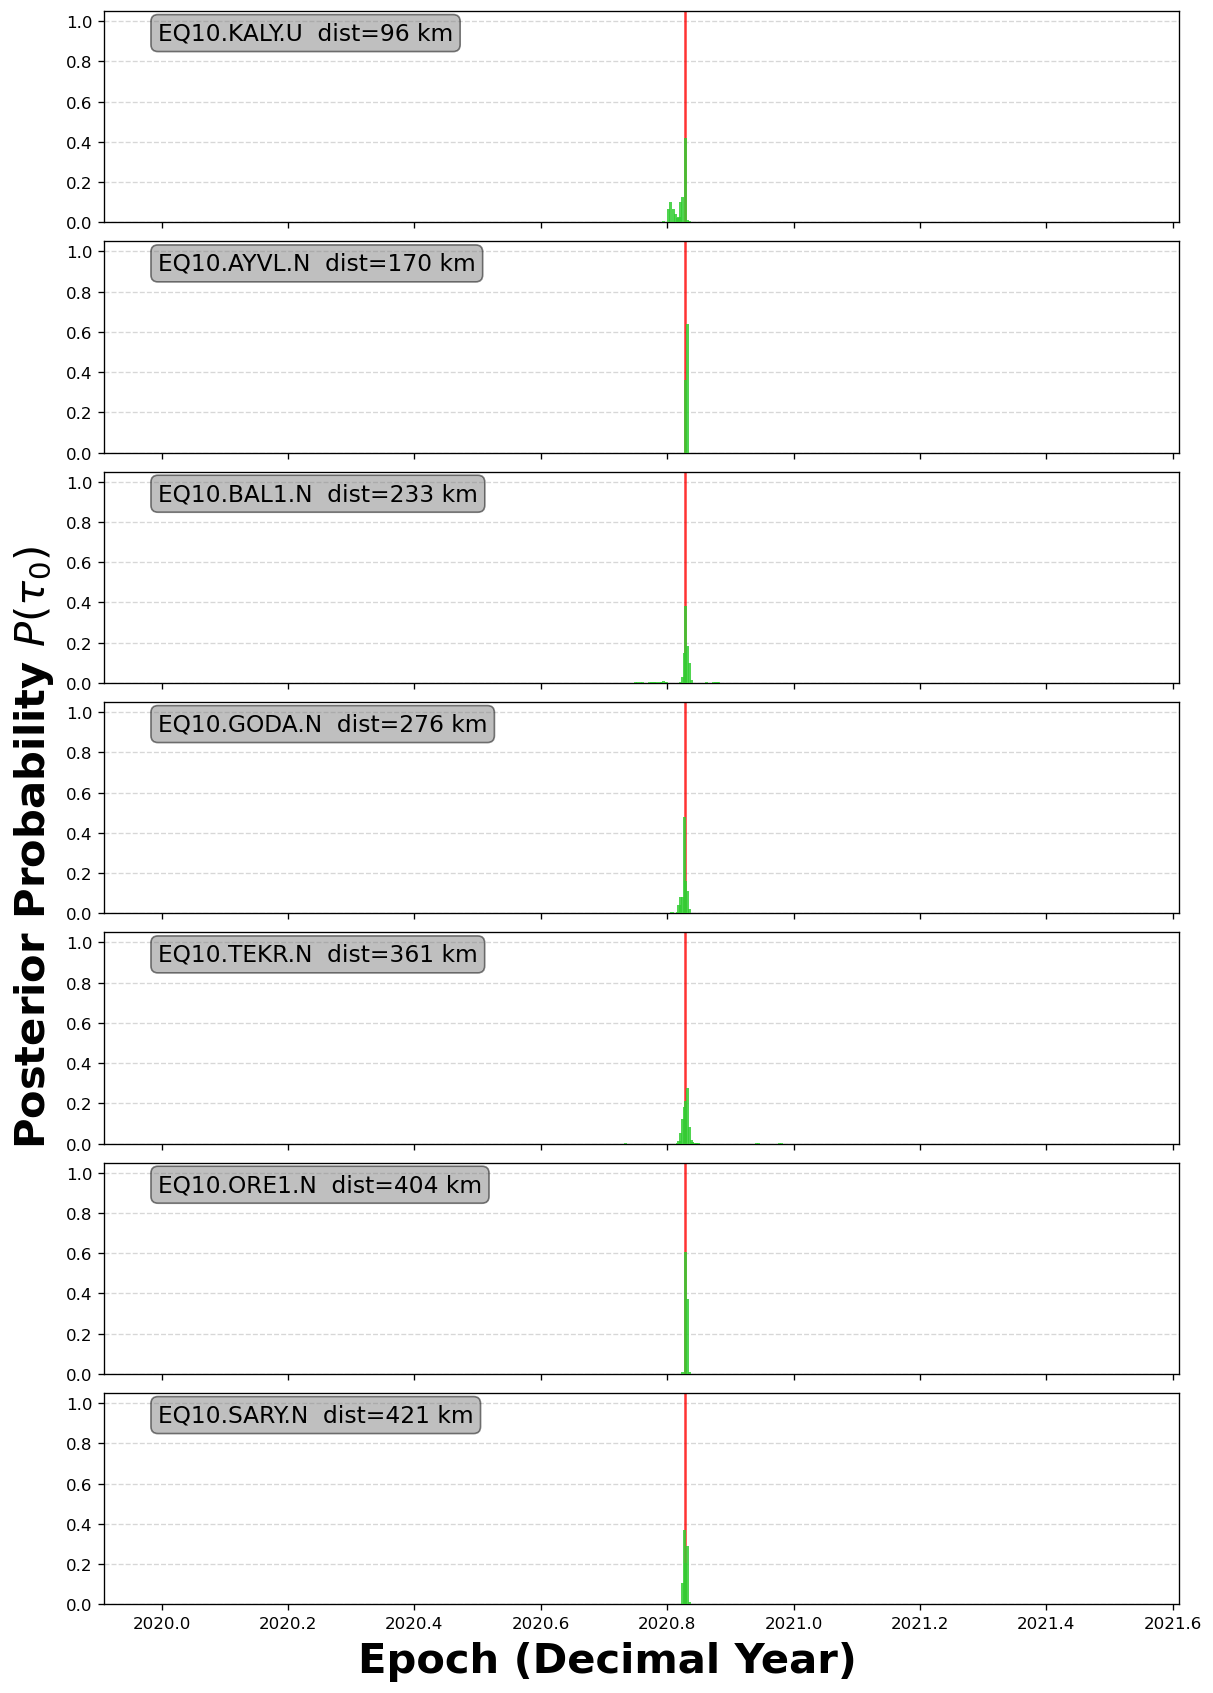

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

events=(
    None,
    2006.0192, # 2006-01-08
    2008.1202, # 2008-02-14
    2008.1202, # 2008-02-14
    2013.7781, # 2013-10-12
    2014.3918, # 2014-05-24
    2015.8767, # 2015-11-17
    2017.5479, # 2017-07-20
    2018.8137, # 2018-10-25
    2020.3333, # 2020-05-02
    2020.8279, # 2020-10-30
)

# Save the Data
#stations = pd.read_csv(f"GNSS_Bayesian/Plot_Time_Series.csv")
stations = pd.read_csv(f"GNSS_Bayesian/Plot_Time_Series_0.1.csv") # For prob>0.1 !!!

EQ = stations['EQ'].tolist()
comp = stations['Component'].tolist()
sta_ids = stations['Station'].tolist()
dist = stations['Distance from Epicenter (m)'].tolist()

#for i in range(1,11):
for i in range(5,11): # For prob>0.1 !!!
    
    # stations that are also predicted by the Okada model for each earthquake
    
    #model = pd.read_csv(f"GNSS_Bayesian/EQ{i}/{i}.csv")
    model = pd.read_csv(f"GNSS_Bayesian/EQ{i}/{i}_0.1.csv") # For prob>0.1 !!!

    model_ids = model['Station'].tolist()
    model_comp = model['Component'].tolist()
    model_pairs = set(zip(model_ids, model_comp))
    
    axes = 0 # start counting how many axes to put in the graph
    for j in range(len(sta_ids)): # For every line
        if (EQ[j]==i): # If it's for the current earthquake being plotted
            filepath = Path(f"GNSS_Bayesian/EQ{i}/{sta_ids[j]}.{comp[j]}.bayes.p_tau")
            if not filepath.exists():
                continue
            axes = axes+1 # count if it exists

    # Now that we know how many axes:
    fig, ax = plt.subplots( # Make Figure
                nrows=axes,
                ncols=1,
                figsize=(10, 2 * axes),
                sharex=True,
                dpi=120,
                layout='constrained'
            )

    k = 0 # counter for the axes
    for j in range(len(sta_ids)): # For every line/ station
        if (EQ[j]==i): # If it's for the current earthquake being plotted
            filepath = Path(f"GNSS_Bayesian/EQ{i}/{sta_ids[j]}.{comp[j]}.bayes.p_tau")
            if not filepath.exists():
                continue

            df = pd.read_csv( # read the file for that station
                filepath,
                sep=r"\s+",  # Matches any amount of whitespace/spaces
                header=None,
                names=["decimal_year", "probability", "amplitude", "std_dev"],
            )

            ax[k].axvline(x=events[i], color="red", alpha=0.8)
            # Plot Probability P(tau0) over Decimal Year
            # Set width ~0.002 (roughly 1 day in decimal year units) so bars don't overlap
            
            if (sta_ids[j], comp[j]) in model_pairs:
                col = "limegreen"
            else:
                col = "black"
            
            ax[k].bar(
                df["decimal_year"],
                df["probability"],
                width=0.005,
                color=col,
                alpha=0.85,
                zorder=5
            )
            ax[k].grid(axis="y", linestyle="--", alpha=0.5)
            ax[k].set_ylim(0, 1.05)  # Probabilities range from 0 to 1
            
            # place a text box in upper left in axes coords
            props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
            distance=round(dist[j]/1000.0)
            ax[k].text(0.05, 0.95, f"EQ{i}.{sta_ids[j]}.{comp[j]}  dist={distance} km", transform=ax[k].transAxes, fontsize=14, verticalalignment='top', bbox=props)

            k = k+1 #update counter for next axis
        else:
            continue
            
    fig.supxlabel(
        "Epoch (Decimal Year)",
        fontsize=15 if i==7 else 25,
        fontweight="bold"
    )
    fig.supylabel(
        "Posterior Probability $P(\\tau_0)$",
        fontsize=15 if i==7 else 25,
        fontweight="bold",
    )
    
    #plt.savefig(f"GNSS_Bayesian/EQ{i}/EQ{i}_Bayesian.png")
    plt.savefig(f"GNSS_Bayesian/EQ{i}/EQ{i}_Bayesian_0.1.png") # For prob>0.1 !!!
    
    plt.show()

# Plot time series for only stations that match the model
Some lines are only for the filtered data with probability>0.1. The alternative is just nonzero probability, which can be as low as 0.00001.

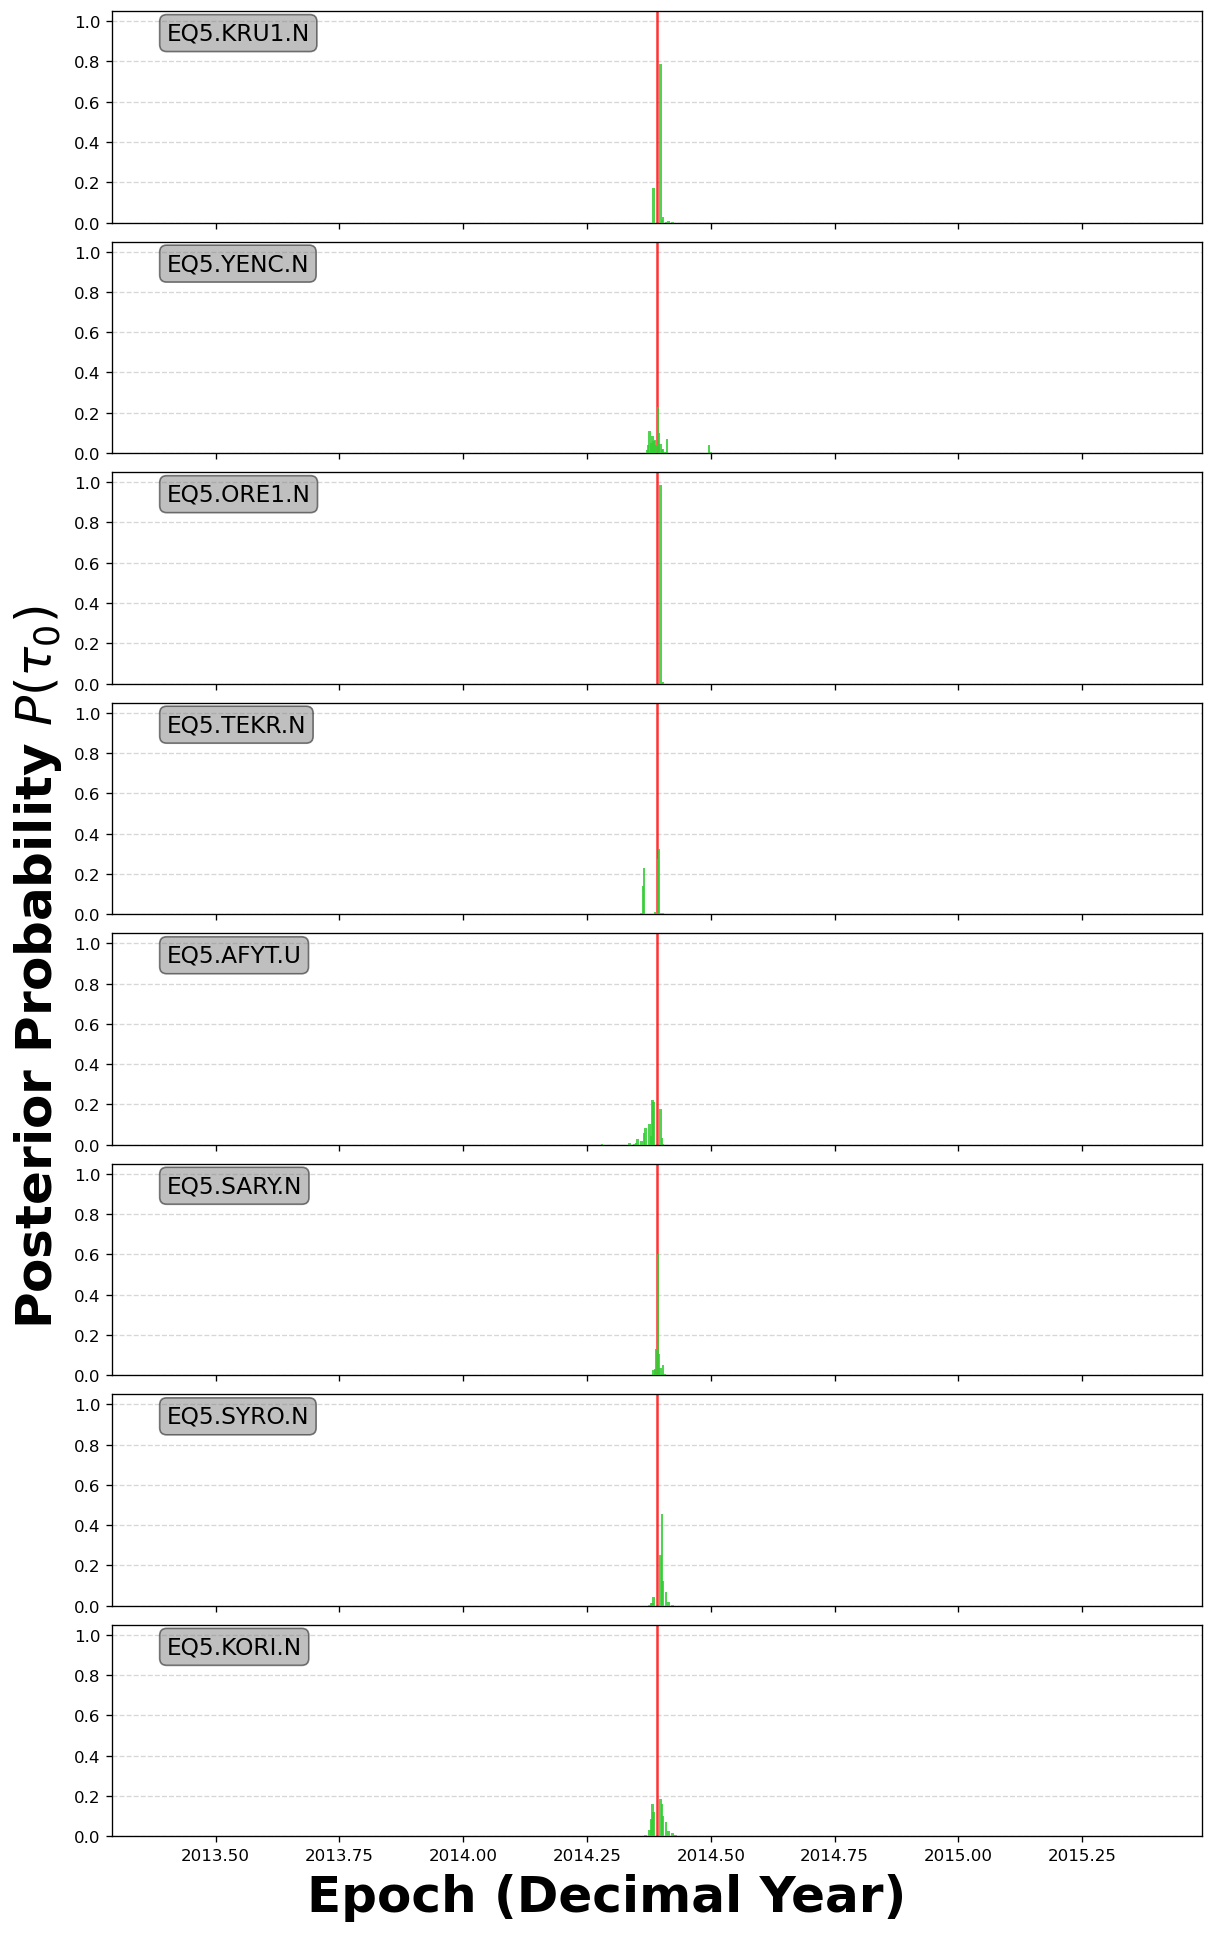

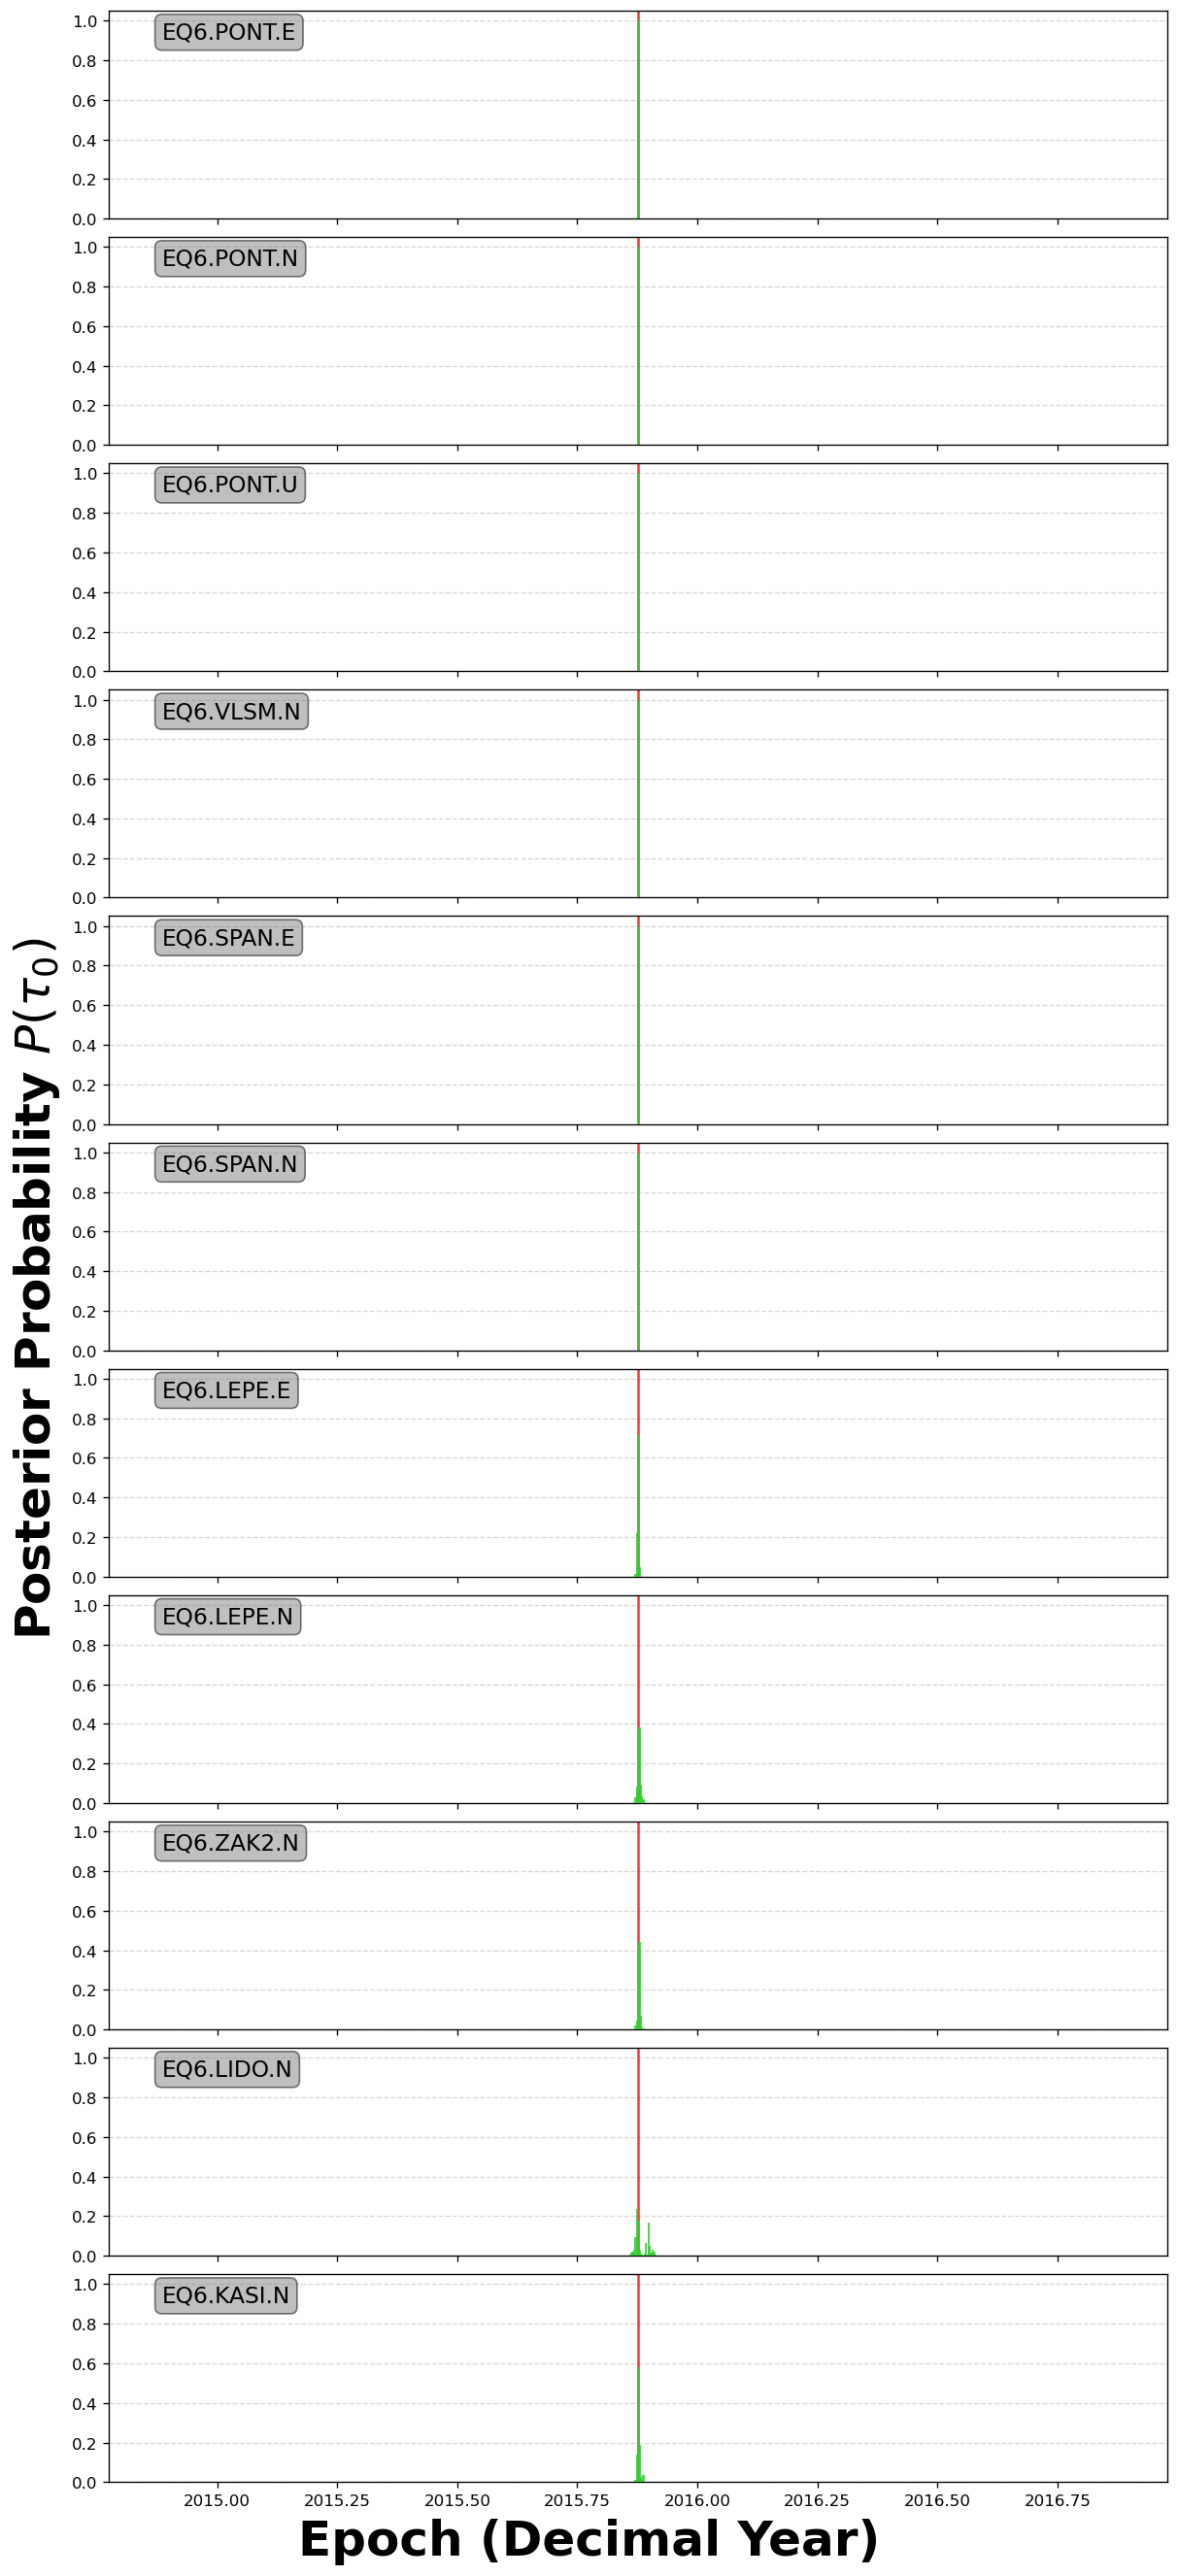

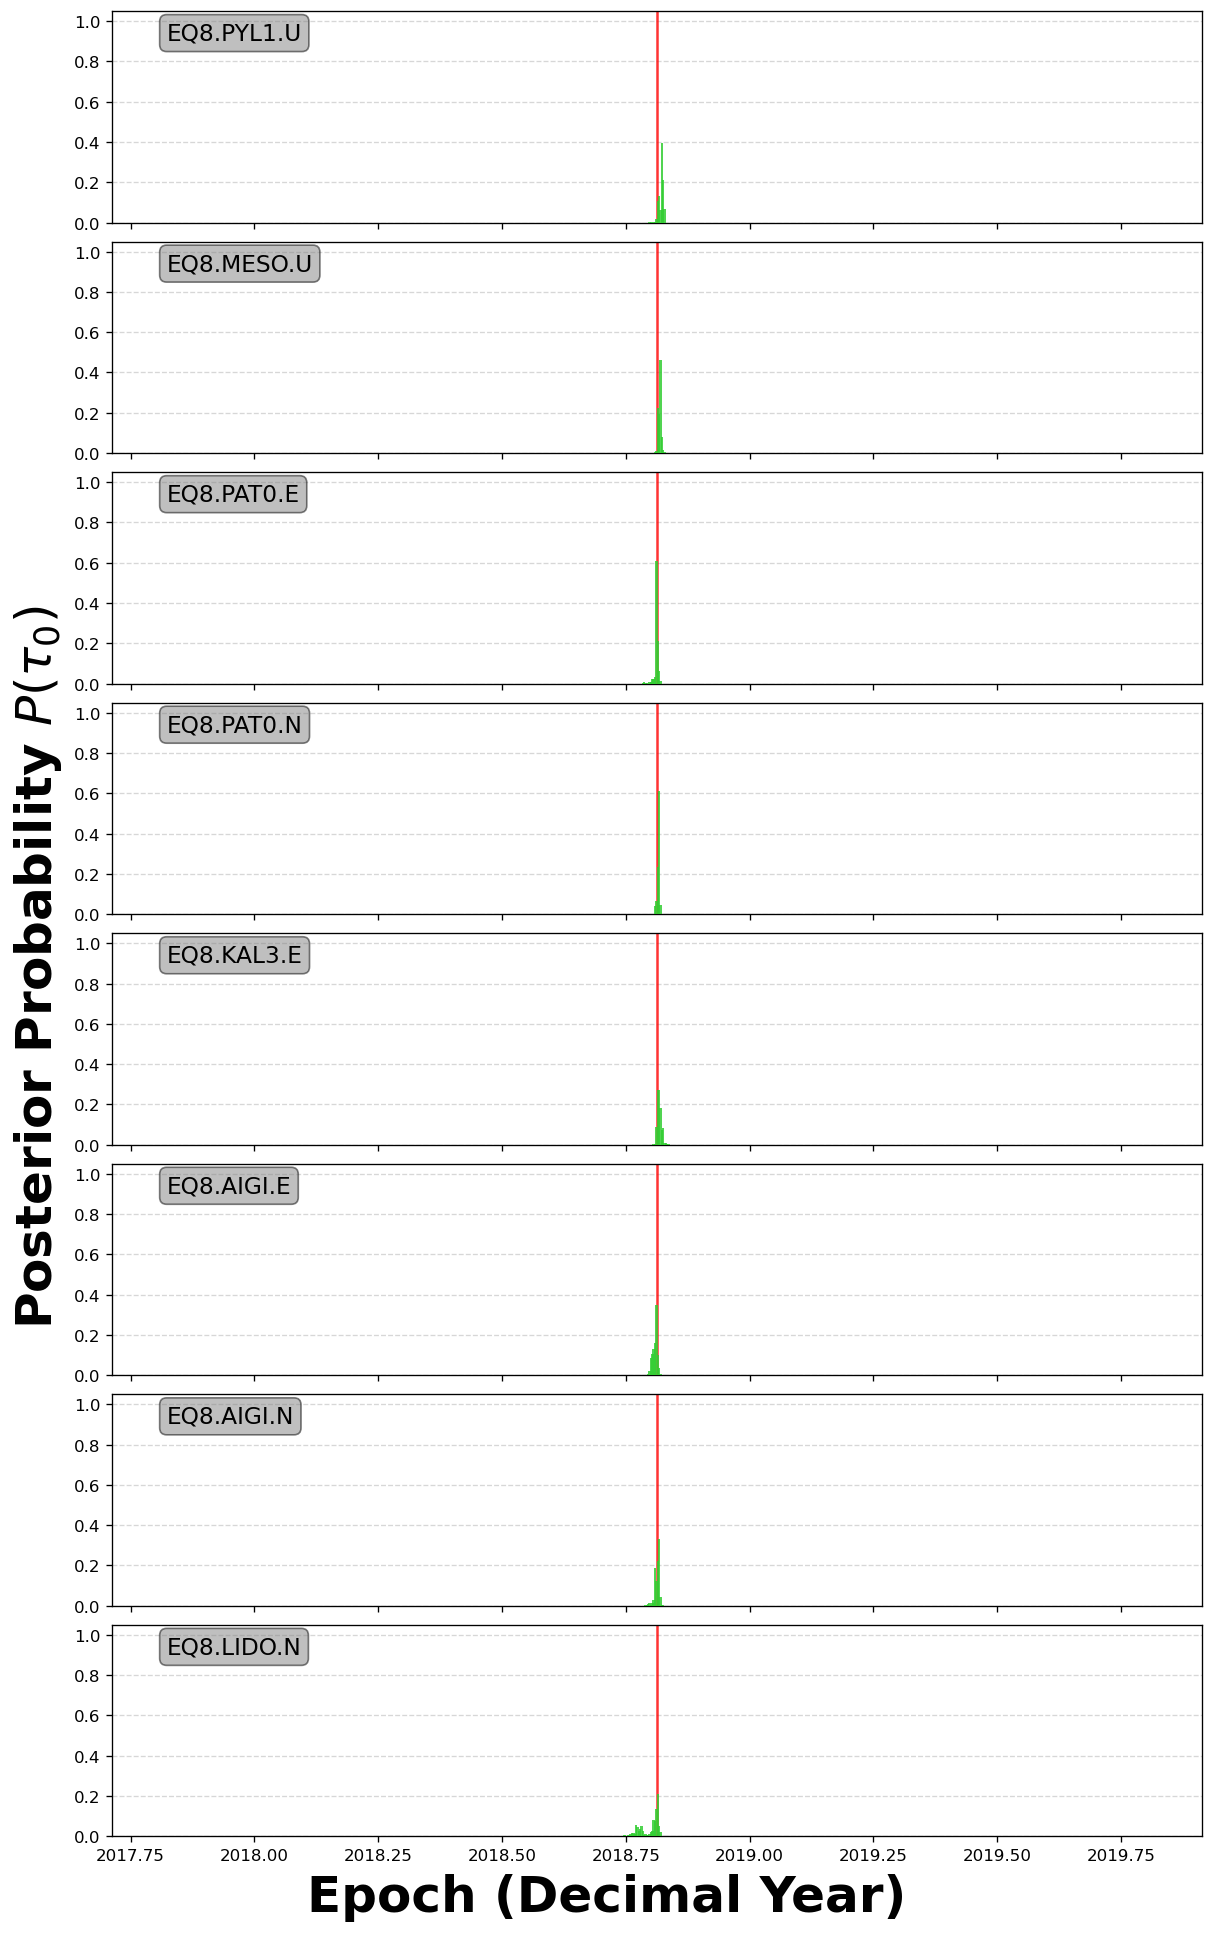

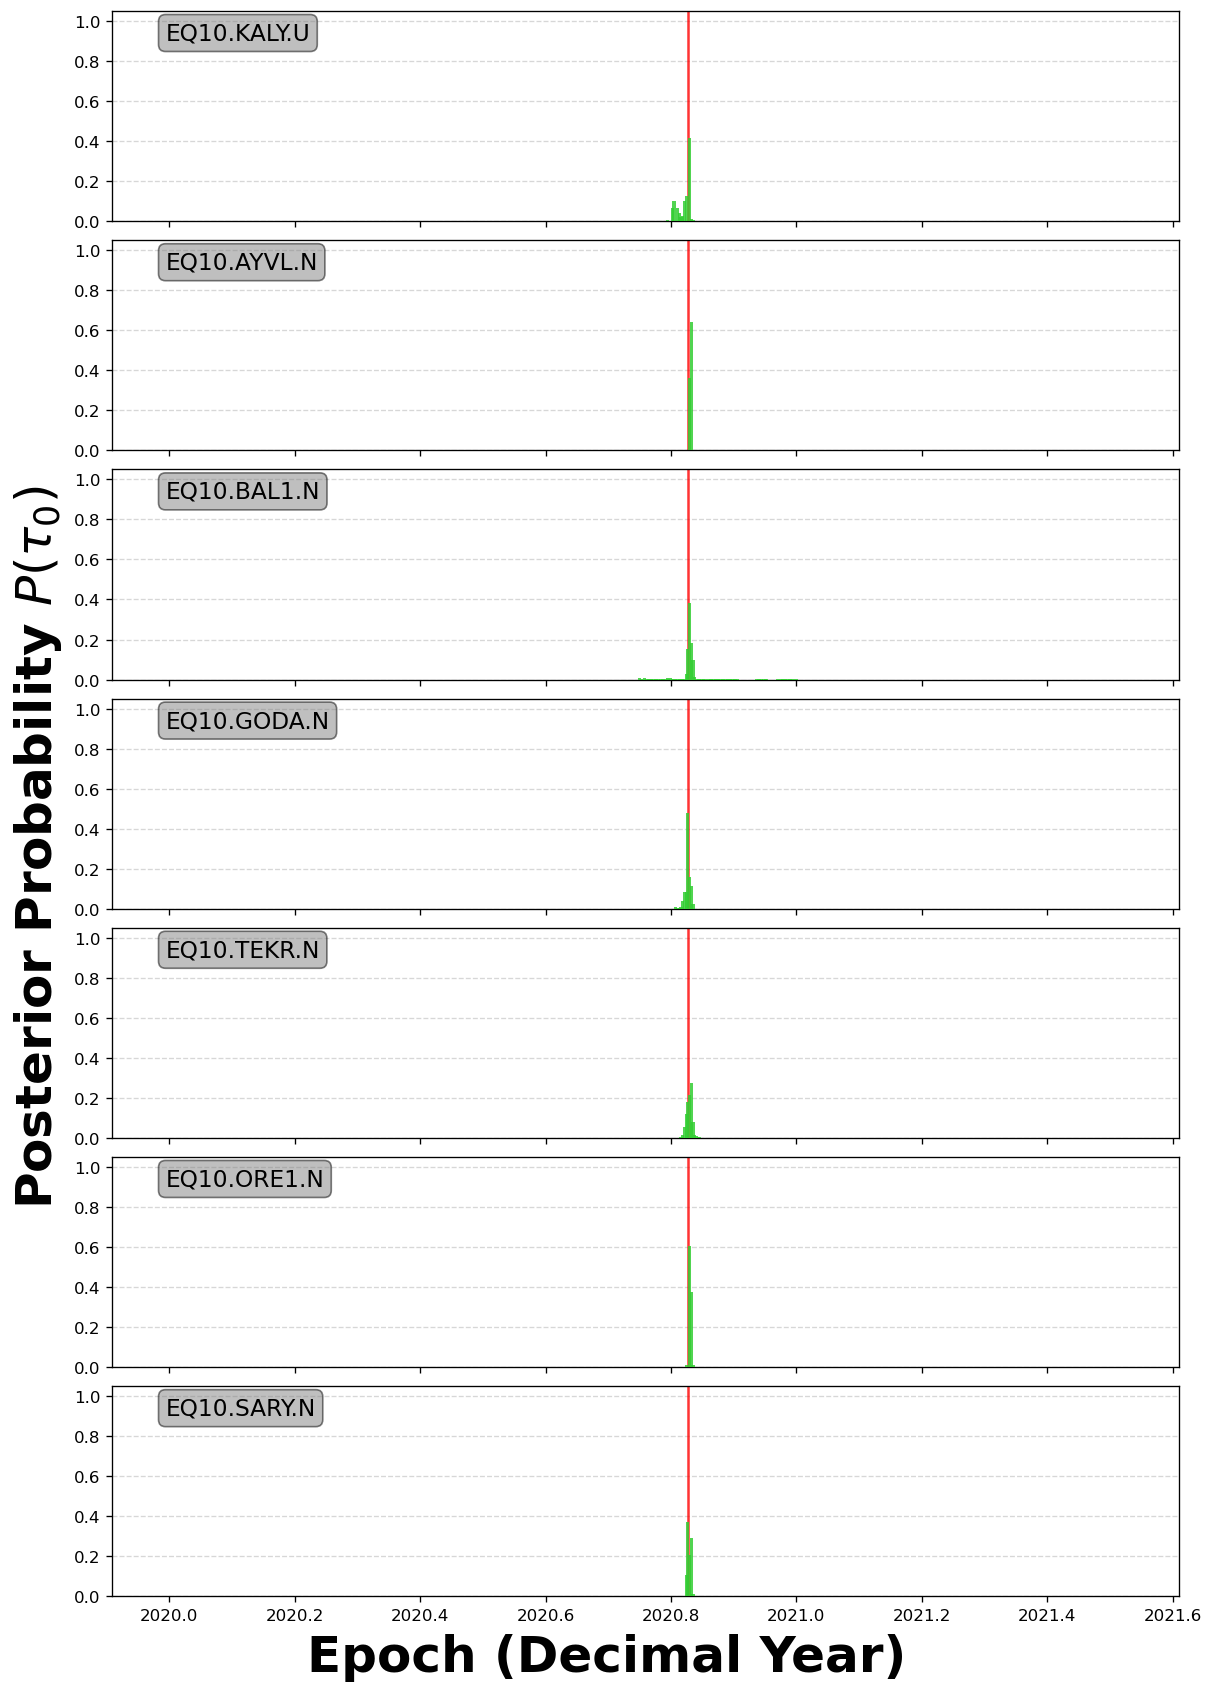

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

events=(
    None,
    2006.0192, # 2006-01-08
    2008.1202, # 2008-02-14
    2008.1202, # 2008-02-14
    2013.7781, # 2013-10-12
    2014.3918, # 2014-05-24
    2015.8767, # 2015-11-17
    2017.5479, # 2017-07-20
    2018.8137, # 2018-10-25
    2020.3333, # 2020-05-02
    2020.8279, # 2020-10-30
)

#for i in (1,5,6,7,8,10): # One plot for each earthquake
for i in (5,6,8,10): # For prob>0.1 !!!
    
    # stations that are also predicted by the Okada model for each earthquake
    #model = pd.read_csv(f"GNSS_Bayesian/EQ{i}/{i}.csv")
    model = pd.read_csv(f"GNSS_Bayesian/EQ{i}/{i}_0.1.csv") # For prob>0.1 !!!
    
    model_ids = model['Station'].tolist()
    comp = model['Component'].tolist()
    
    axes = 0 # start counting how many axes to put in the graph
    for j in range(len(model_ids)): # For every line
        filepath = Path(f"GNSS_Bayesian/EQ{i}/{model_ids[j]}.{comp[j]}.bayes.p_tau")
        if not filepath.exists():
            continue
        axes = axes+1 # count if it exists

    # Now that we know how many axes:
    fig, ax = plt.subplots( # Make Figure
                nrows=axes,
                ncols=1,
                figsize=(10, 2 * axes),
                sharex=True,
                dpi=120,
                layout='constrained'
            )

    k = 0 # counter for the axes
    for j in range(len(model_ids)): # For every line/ station
        filepath = Path(f"GNSS_Bayesian/EQ{i}/{model_ids[j]}.{comp[j]}.bayes.p_tau")
        if not filepath.exists():
            continue

        df = pd.read_csv( # read the file for that station
            filepath,
            sep=r"\s+",  # Matches any amount of whitespace/spaces
            header=None,
            names=["decimal_year", "probability", "amplitude", "std_dev"],
        )
    
        # Plot Probability P(tau0) over Decimal Year
        # Set width ~0.002 (roughly 1 day in decimal year units) so bars don't overlap  
        ax[k].bar(
            df["decimal_year"],
            df["probability"],
            width=0.005,
            color="limegreen",
            alpha=0.85,
            zorder=5
        )
        ax[k].grid(axis="y", linestyle="--", alpha=0.5)
        ax[k].axvline(x=events[i], color="red", alpha=0.8)
        ax[k].set_ylim(0, 1.05)  # Probabilities range from 0 to 1
        
        # place a text box in upper left in axes coords
        props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
        ax[k].text(0.05, 0.95, f"EQ{i}.{model_ids[j]}.{comp[j]}", transform=ax[k].transAxes, fontsize=14, verticalalignment='top', bbox=props)

        k = k+1 #update counter for next axis
            
    fig.supxlabel(
        "Epoch (Decimal Year)", fontsize=30, fontweight="bold"
    )
    fig.supylabel(
        "Posterior Probability $P(\\tau_0)$",
        fontsize=30,
        fontweight="bold",
    )
    
    #plt.savefig(f"GNSS_Bayesian/EQ{i}/EQ{i}_Model.png")
    plt.savefig(f"GNSS_Bayesian/EQ{i}/EQ{i}_Model_0.1.png") # For prob>0.1 !!!
    plt.show()

# Plot time series for only stations that match the model (single station version)
Only for nonzero probability, which can be as low as 0.00001.

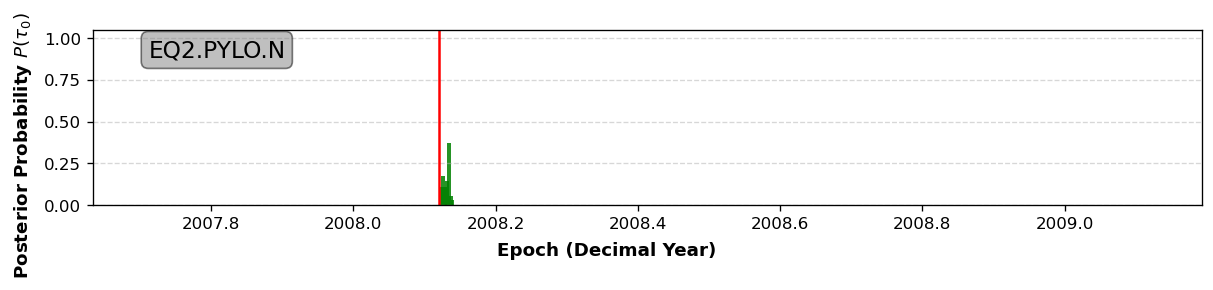

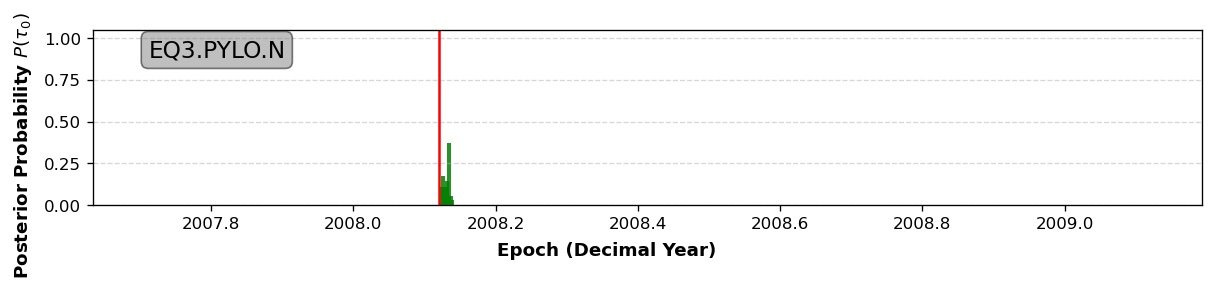

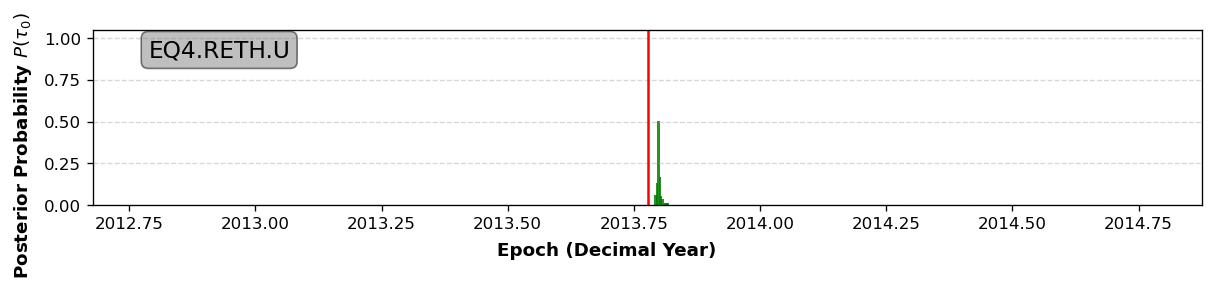

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

events=(
    None,
    2006.0192, # 2006-01-08
    2008.1202, # 2008-02-14
    2008.1202, # 2008-02-14
    2013.7781, # 2013-10-12
    2014.3918, # 2014-05-24
    2015.8767, # 2015-11-17
    2017.5479, # 2017-07-20
    2018.8137, # 2018-10-25
    2020.3333, # 2020-05-02
    2020.8279, # 2020-10-30
)

for i in (2,3,4): # One plot for each earthquake
    # stations that are also predicted by the Okada model for each earthquake
    
    model = pd.read_csv(f"GNSS_Bayesian/EQ{i}/{i}.csv")
    
    model_ids = model['Station'].tolist()
    comp = model['Component'].tolist()

    # Now that we know how many axes:
    fig, ax = plt.subplots( # Make Figure
                figsize=(10, 2),
                sharex=True,
                dpi=120,
                layout='constrained'
            )

    for j in range(len(model_ids)): # For every line/ station
        filepath = Path(f"GNSS_Bayesian/EQ{i}/{model_ids[j]}.{comp[j]}.bayes.p_tau")
        if not filepath.exists():
            continue

        df = pd.read_csv( # read the file for that station
            filepath,
            sep=r"\s+",  # Matches any amount of whitespace/spaces
            header=None,
            names=["decimal_year", "probability", "amplitude", "std_dev"],
        )
    
        # Plot Probability P(tau0) over Decimal Year
        # Set width ~0.002 (roughly 1 day in decimal year units) so bars don't overlap  
        ax.bar(
            df["decimal_year"],
            df["probability"],
            width=0.005,
            color="green",
            alpha=0.85,
        )
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.axvline(x=events[i], color="red")
        ax.set_ylim(0, 1.05)  # Probabilities range from 0 to 1
        
        # place a text box in upper left in axes coords
        props = dict(boxstyle='round', facecolor='grey', alpha=0.5)
        ax.text(0.05, 0.95, f"EQ{i}.{model_ids[j]}.{comp[j]}", transform=ax.transAxes, fontsize=14, verticalalignment='top', bbox=props)
            
    fig.supxlabel(
        "Epoch (Decimal Year)", fontsize=11, fontweight="bold"
    )
    fig.supylabel(
        "Posterior Probability $P(\\tau_0)$",
        fontsize=11,
        fontweight="bold",
    )
    
    plt.savefig(f"GNSS_Bayesian/EQ{i}/EQ{i}_Model.png")
    
    plt.show()